In [ ]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image
from torch.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModel, AutoProcessor

: 

In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", torch.cuda.get_device_properties(0).total_memory / 1e9, "GB")

device: cuda
GPU: NVIDIA GeForce GTX 1650
VRAM: 4.294705152 GB


In [15]:
class PairDataset(Dataset):
    def __init__(self, df, processor):
        self.df = df.reset_index(drop=True)
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["crop_path"]).convert("RGB")
        text = row["text"]

        img_inputs = self.processor(images=img, return_tensors="pt")
        txt_inputs = self.processor(
            text=text,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=64,
        )

        return {
            "pixel_values": img_inputs["pixel_values"][0],
            "input_ids": txt_inputs["input_ids"][0],
        }

In [ ]:
train_df = pd.read_csv("train_pairs_train.csv")
val_df = pd.read_csv("train_pairs_val.csv")
print("train:", len(train_df), "val:", len(val_df))

MODEL_NAME = "google/siglip2-base-patch16-384"
processor = AutoProcessor.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(device).float()

for n, p in model.named_parameters():
    if "logit" in n:
        p.requires_grad = True

with torch.no_grad():
    model.logit_bias.data.fill_(0.0)
    model.logit_scale.data.fill_(np.log(10.0))

print("logit_scale:", model.logit_scale.data.item())
print("logit_bias:", model.logit_bias.data.item())

BATCH_SIZE = 2
ACCUM_STEPS = 8
NUM_EPOCHS = 5
LR = 1e-5

train_ds = PairDataset(train_df, processor)
val_ds = PairDataset(val_df, processor)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True
)

optimizer = torch.optim.AdamW(
    [
        {
            "params": [
                p
                for n, p in model.named_parameters()
                if "logit" not in n and p.requires_grad
            ],
            "lr": 1e-5,
        },
        {"params": [model.logit_scale, model.logit_bias], "lr": 1e-3},
    ],
    weight_decay=0.01,
)
scaler = GradScaler(device="cuda")

train: 1881 val: 209


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

logit_scale: 2.3025851249694824
logit_bias: 0.0


In [17]:
def siglip_loss(img_emb, txt_emb, logit_scale, logit_bias):
    logits = img_emb @ txt_emb.T * logit_scale + logit_bias
    batch_size = img_emb.shape[0]
    labels = 2 * torch.eye(batch_size, device=img_emb.device) - 1
    return -F.logsigmoid(labels * logits).sum() / batch_size


logit_scale = model.logit_scale
logit_bias = model.logit_bias
print("logit_scale:", logit_scale.data.item())
print("logit_bias:", logit_bias.data.item())


def forward_batch(batch):
    pixel_values = batch["pixel_values"].to(device)
    input_ids = batch["input_ids"].to(device)

    with autocast(device_type="cuda", dtype=torch.float16):
        img_out = model.get_image_features(pixel_values=pixel_values, return_dict=True)
        img_emb = (
            img_out.pooler_output if hasattr(img_out, "pooler_output") else img_out
        )

        txt_out = model.get_text_features(input_ids=input_ids, return_dict=True)
        txt_emb = (
            txt_out.pooler_output if hasattr(txt_out, "pooler_output") else txt_out
        )

    img_emb = F.normalize(img_emb.float(), dim=-1)
    txt_emb = F.normalize(txt_emb.float(), dim=-1)
    return img_emb, txt_emb


@torch.no_grad()
def evaluate():
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for batch in val_loader:
        img_emb, txt_emb = forward_batch(batch)
        loss = siglip_loss(img_emb, txt_emb, logit_scale, logit_bias)
        total_loss += loss.item()

        sims = img_emb @ txt_emb.T
        preds = sims.argmax(dim=1)
        correct = (preds == torch.arange(len(preds), device=device)).sum().item()
        total_correct += correct
        total += len(preds)

    return total_loss / len(val_loader), total_correct / total

logit_scale: 2.3025851249694824
logit_bias: 0.0


In [18]:
batch = next(iter(train_loader))
img_emb, txt_emb = forward_batch(batch)
logits = img_emb @ txt_emb.T * model.logit_scale + model.logit_bias
print("diag:", logits.diag().tolist())
print("loss:", siglip_loss(img_emb, txt_emb, model.logit_scale, model.logit_bias).item())

diag: [0.1617981195449829, 0.14684394001960754]
loss: 1.386451005935669


In [19]:
history = {"train_loss": [], "val_loss": [], "val_acc": []}
no_improve = 0
PATIENCE = 2
global_step = 0
best_val_acc = 0.0

print(
    f"Старт: {NUM_EPOCHS} эпох, batch={BATCH_SIZE}, accum={ACCUM_STEPS} (эффективный={BATCH_SIZE * ACCUM_STEPS})"
)
print(f"train: {len(train_ds)}, val: {len(val_ds)}")
print()

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0.0
    epoch_start = time.time()
    optimizer.zero_grad()

    pbar = tqdm(train_loader, desc=f"Эпоха {epoch + 1}/{NUM_EPOCHS}")
    for step, batch in enumerate(pbar):
        img_emb, txt_emb = forward_batch(batch)
        loss = siglip_loss(img_emb, txt_emb, logit_scale, logit_bias)
        loss = loss / ACCUM_STEPS

        scaler.scale(loss).backward()

        if (step + 1) % ACCUM_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            global_step += 1

        epoch_loss += loss.item() * ACCUM_STEPS
        pbar.set_postfix(
            {
                "loss": f"{loss.item() * ACCUM_STEPS:.4f}",
                "step": global_step,
            }
        )

    avg_train_loss = epoch_loss / len(train_loader)
    val_loss, val_acc = evaluate()
    epoch_time = time.time() - epoch_start

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"\nЭпоха {epoch + 1}/{NUM_EPOCHS} | train_loss={avg_train_loss:.4f} | val_loss={val_loss:.4f} | val_top1_acc={val_acc:.3f} | time={epoch_time:.1f}s"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        no_improve = 0
        torch.save(model.state_dict(), "siglip_full_best.pt")
        print(f"  ↑ новый лучший: {best_val_acc:.3f} — сохранён в siglip_full_best.pt")
    else:
        no_improve += 1
        print(f"  нет улучшения ({no_improve}/{PATIENCE})")

    if no_improve >= PATIENCE:
        print("Early stopping")
        break

torch.save(model.state_dict(), "siglip_full_last.pt")
print("\nФинальные веса: siglip_full_last.pt")

Старт: 5 эпох, batch=2, accum=8 (эффективный=16)
train: 1881, val: 209



Эпоха 1/5:   0%|          | 0/941 [00:00<?, ?it/s]


Эпоха 1/5 | train_loss=1.0469 | val_loss=0.9419 | val_top1_acc=0.971 | time=3933.0s
  ↑ новый лучший: 0.971 — сохранён в siglip_full_best.pt


Эпоха 2/5:   0%|          | 0/941 [00:00<?, ?it/s]


Эпоха 2/5 | train_loss=0.8299 | val_loss=0.8489 | val_top1_acc=0.971 | time=3894.8s
  нет улучшения (1/2)


Эпоха 3/5:   0%|          | 0/941 [00:00<?, ?it/s]


Эпоха 3/5 | train_loss=0.7371 | val_loss=0.8045 | val_top1_acc=0.962 | time=3906.0s
  нет улучшения (2/2)
Early stopping

Финальные веса: siglip_full_last.pt


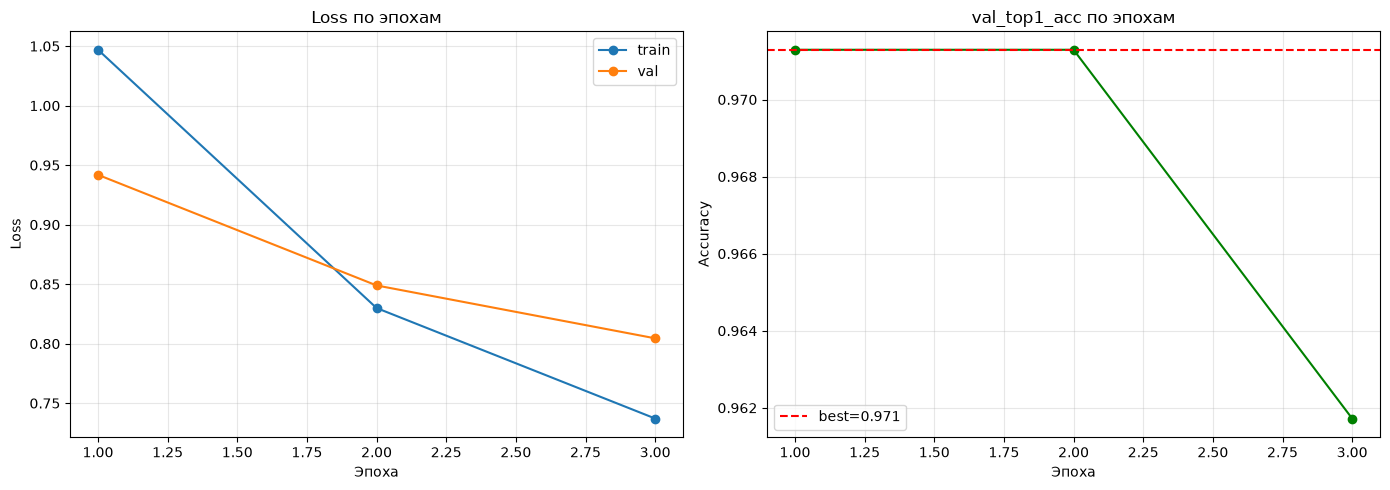

график сохранён: training_history.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs, history["train_loss"], marker="o", label="train")
axes[0].plot(epochs, history["val_loss"], marker="o", label="val")
axes[0].set_title("Loss по эпохам")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history["val_acc"], marker="o", color="green")
axes[1].set_title("val_top1_acc по эпохам")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Accuracy")
axes[1].axhline(
    best_val_acc, color="red", linestyle="--", label=f"best={best_val_acc:.3f}"
)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()